# Millor model global i anàlisi d'errors

---

## Objectiu

Aquest notebook tanca el cicle de modelització identificant el **millor model a nivell global**
(entre els tres blocs: tabular, espectral i híbrid) i analitzant en detall els **errors sobre el
conjunt de hold-out**. L'anàlisi inclou:

1. **Comparació global** — taula consolidada dels tres blocs amb mètriques de CV i hold-out.
2. **Prediccions del millor model** sobre el hold-out (model híbrid seleccionat al bloc 08).
3. **Anàlisi d'errors per subjecte** — quins infants s'han classificat malament i per quant.
4. **Visualitzacions** — matriu de confusió, corba ROC/PR i projecció PCA marcant errors.

El *hold-out* (29 infants, 3 amb dislèxia) s'avalua exactament una vegada, amb el **llindar
derivat del màxim F2 sobre les prediccions OOF** del bloc 08 (mai del hold-out directament).


## 0. Imports i configuració

In [1]:
import sys, json, pickle, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import rankdata

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve,
    ConfusionMatrixDisplay, roc_auc_score, average_precision_score,
    f1_score, fbeta_score, recall_score,
)

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
from utils.data_loading import load_dataset
from utils.metrics import compute_metrics

sns.set_theme(style='whitegrid', font_scale=1.1)
RANDOM_STATE = 42
OUTPUTS    = ROOT / 'outputs'
SPLIT_PATH = OUTPUTS / 'holdout_split.json'

print(f'Root: {ROOT}')
print(f'Outputs: {OUTPUTS}')


Root: c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection
Outputs: c:\Users\Marçal\OneDrive\Escriptori\TFG\dyslexia-detection\outputs


## 1. Càrrega dels artefactes dels tres blocs

In [2]:
# ── Models exportats ─────────────────────────────────────────────
with open(OUTPUTS / 'tabular_model.pkl', 'rb') as f:
    TAB_MODEL = pickle.load(f)                    # Pipeline(StandardScaler + LogReg, bloc 06)

AUD_BUNDLE   = joblib.load(OUTPUTS / 'final_model.joblib')   # {scaler, clf}, bloc 07
HYB_BUNDLE   = joblib.load(OUTPUTS / 'final_hybrid_model.joblib')  # bloc 08, millor model global

thr_hybrid = HYB_BUNDLE['threshold']
strategy   = HYB_BUNDLE['strategy']   # 'late_avg'

# ── Mètriques de CV desades als CSVs ─────────────────────────────
tab_comp = pd.read_csv(OUTPUTS / 'tabular_harmon_comparison.csv')
hyb_comp = pd.read_csv(OUTPUTS / 'hybrid_comparison.csv')

# ── Resums hold-out dels blocs 07 i 08 ───────────────────────────
with open(OUTPUTS / 'final_model_holdout.json', encoding='utf-8') as f:
    spec_ho = json.load(f)
with open(OUTPUTS / 'final_hybrid_holdout.json', encoding='utf-8') as f:
    hyb_ho_json = json.load(f)

# ── Millor model tabular ──────────────────────────────────────────
best_tab = tab_comp.loc[tab_comp['auc_roc_nested'].idxmax()]

print(f"Millor model tabular  : {best_tab['model']}  "
      f"(AUC-ROC CV = {best_tab['auc_roc_nested']:.3f} ± {best_tab['auc_roc_nested_std']:.3f},"
      f"  p = {best_tab['p_roc']:.3f})")
print(f"Model espectral       : {spec_ho['backbone']} + {spec_ho['cap']}  "
      f"(AUC-ROC CV = {spec_ho['cv_auc_roc']:.3f}  "
      f"[{spec_ho['cv_roc_lo']:.3f},{spec_ho['cv_roc_hi']:.3f}],  "
      f"p = {spec_ho['cv_p_roc']:.3f})")
print(f"Model híbrid          : {hyb_ho_json['estrategia']}  "
      f"(AUC-ROC CV = {hyb_ho_json['cv_auc_roc']:.3f}  "
      f"[{hyb_ho_json['cv_roc_ci'][0]:.3f},{hyb_ho_json['cv_roc_ci'][1]:.3f}],  "
      f"p = {hyb_ho_json['cv_p_roc']:.3f})")
print(f"\nEstrategia guanyadora: {strategy}  |  llindar: {thr_hybrid:.4f}")


Millor model tabular  : Regressió Logística  (AUC-ROC CV = 0.916 ± 0.097,  p = 0.002)
Model espectral       : WavLM-base + Linear probe  (AUC-ROC CV = 0.912  [0.840,0.966],  p = 0.002)
Model híbrid          : Fusió late (calibrada)  (AUC-ROC CV = 0.945  [0.858,1.000],  p = 0.002)

Estrategia guanyadora: late_cal  |  llindar: 0.2651


## 2. Comparació global dels tres blocs

La taula recull la **mètrica de selecció** (AUC-ROC de CV) i les principals mètriques del
*hold-out* per als tres blocs. Les mètriques de llindar (F2, sensibilitat) del bloc tabular
no s'han guardat en un fitxer independent; la referència principal és l'AUC-ROC.


In [ ]:
rows = [
    {
        'Bloc': '06 — Tabular',
        'Model': best_tab['model'],
        'AUC-ROC CV': f"{best_tab['auc_roc_nested']:.3f} ± {best_tab['auc_roc_nested_std']:.3f}",
        'IC 95% CV': f"[{best_tab['roc_lo']:.3f}, {best_tab['roc_hi']:.3f}]",
        'p (perm)': f"{best_tab['p_roc']:.3f}",
        'AUC-ROC HO': f"{best_tab['']}",
        'Sensibilitat HO': '—',
        'F2 HO': '—',
    },
    {
        'Bloc': '07 — Espectral',
        'Model': f"{spec_ho['backbone']} + {spec_ho['cap']}",
        'AUC-ROC CV': f"{spec_ho['cv_auc_roc']:.3f}",
        'IC 95% CV': f"[{spec_ho['cv_roc_lo']:.3f}, {spec_ho['cv_roc_hi']:.3f}]",
        'p (perm)': f"{spec_ho['cv_p_roc']:.3f}",
        'AUC-ROC HO': f"{spec_ho['holdout_auc_roc']:.3f}",
        'Sensibilitat HO': '—',
        'F2 HO': '—',
    },
    {
        'Bloc': '08 — Híbrid  ★',
        'Model': hyb_ho_json['estrategia'],
        'AUC-ROC CV': f"{hyb_ho_json['cv_auc_roc']:.3f}",
        'IC 95% CV': f"[{hyb_ho_json['cv_roc_ci'][0]:.3f}, {hyb_ho_json['cv_roc_ci'][1]:.3f}]",
        'p (perm)': f"{hyb_ho_json['cv_p_roc']:.3f}",
        'AUC-ROC HO': f"{hyb_ho_json['holdout']['auc_roc']:.3f}",
        'Sensibilitat HO': f"{hyb_ho_json['holdout']['sensibilitat']:.3f}",
        'F2 HO': f"{hyb_ho_json['holdout']['f2']:.3f}",
    },
]

df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
print('\n★ Model seleccionat per al present notebook.')


          Bloc                     Model    AUC-ROC CV      IC 95% CV p (perm) AUC-ROC HO Sensibilitat HO F2 HO
  06 — Tabular       Regressió Logística 0.916 ± 0.097 [0.738, 0.982]    0.002          —               —     —
07 — Espectral WavLM-base + Linear probe         0.912 [0.840, 0.966]    0.002      0.910               —     —
08 — Híbrid  ★    Fusió late (calibrada)         0.945 [0.858, 1.000]    0.002      0.974           0.667 0.714

★ Model seleccionat per al present notebook.


## 3. Càrrega del conjunt de hold-out

Per reconstruir les prediccions del model híbrid sobre el hold-out cal alinear les dues modalitats
exactament com al bloc 08: les característiques tabulars via `load_dataset` i els *embeddings*
WavLM via `emb_WavLM.npy` + `mel_fragments.npz`.


In [4]:
# ── Dades tabulars ───────────────────────────────────────────────
data_info = load_dataset(random_state=RANDOM_STATE, split_path=SPLIT_PATH)
FEAT_NAMES = data_info['feature_names']

X_train = data_info['X_train']
y_train = data_info['y_train']

def subject_key(df):
    return (df['nom'].astype(str) + '|' + df['escola'].astype(str)
            + '|' + df['classe'].astype(str)).values

tab_X_by_s = {}
tab_y_by_s = {}
for part, Xkey, ykey, dfkey in [('train', 'X_train', 'y_train', 'df_train'),
                                 ('hold',  'X_hold',  'y_hold',  'df_hold')]:
    keys = subject_key(data_info[dfkey])
    for k, xrow, yval in zip(keys, data_info[Xkey], data_info[ykey]):
        tab_X_by_s[k] = np.asarray(xrow, dtype=np.float32)
        tab_y_by_s[k] = int(yval)

# ── Embeddings WavLM (mean-pool per subjecte) ────────────────────
_d     = np.load(OUTPUTS / 'mel_fragments.npz', allow_pickle=True)
y_frag = _d['y_all']; g_frag = _d['g_all']; s_frag = _d['s_all']
E_wl   = np.load(OUTPUTS / 'emb_WavLM.npy')

subj_aud  = np.unique(g_frag)
Xaud_by_s = {s: E_wl[g_frag == s].mean(axis=0) for s in subj_aud}
yaud_by_s = {s: int(y_frag[g_frag == s][0])     for s in subj_aud}
spl_by_s  = {s: str(s_frag[g_frag == s][0])     for s in subj_aud}

# ── Alineació per clau composta ───────────────────────────────────
common = [s for s in subj_aud if str(s) in tab_X_by_s]
assert len(common) == 141, f'S\'esperaven 141 subjectes, n\'hi ha {len(common)}'

Xtab_all  = np.vstack([tab_X_by_s[str(s)] for s in common]).astype(np.float32)
Xaud_all  = np.vstack([Xaud_by_s[s]       for s in common]).astype(np.float32)
y_all     = np.array([yaud_by_s[s]        for s in common], dtype=int)
split_all = np.array([spl_by_s[s]         for s in common])

train_mask = split_all == 'train'
hold_mask  = split_all == 'hold'

Xt_tr, Xa_tr, y_tr = Xtab_all[train_mask], Xaud_all[train_mask], y_all[train_mask]
Xt_ho, Xa_ho, y_ho = Xtab_all[hold_mask],  Xaud_all[hold_mask],  y_all[hold_mask]

# ── Reindexar df_hold per coincidir amb l'ordre híbrid ───────────
# common és ordenat per np.unique (alfabèticament); data_info['df_hold'] segueix
# l'ordre del CSV. Cal alinear-los perquè p_hold / y_pred apuntin al subjecte
# correcte en la taula d'errors i en totes les visualitzacions.
_df_hold_keys = subject_key(data_info['df_hold'])
_key_to_row   = {k: i for i, k in enumerate(_df_hold_keys)}
_hold_subs    = [common[i] for i in range(len(common)) if hold_mask[i]]
df_hold = (data_info['df_hold']
           .iloc[[_key_to_row[str(s)] for s in _hold_subs]]
           .reset_index(drop=True))

assert (df_hold['dislexia'].values == y_ho).all(), \
    'Desalineament df_hold / y_ho — revisa la clau composta!'
assert int(y_ho.sum()) == 3, 'S\'esperaven 3 positius al hold-out'

print(f'Divisió: {data_info["split_source"]}')
print(f'Train: {train_mask.sum()} infants ({int(y_tr.sum())} dislèxia)')
print(f'Hold-out: {hold_mask.sum()} infants ({int(y_ho.sum())} dislèxia)')
print('Alineació df_hold / y_ho: OK')


Divisió: loaded
Train: 112 infants (10 dislèxia)
Hold-out: 29 infants (3 dislèxia)
Alineació df_hold / y_ho: OK


## 4. Prediccions del millor model sobre el hold-out

S'aplica el model híbrid final (carregat de `final_hybrid_model.joblib`) als 29 infants del
hold-out. La funció `predict_hybrid` reconstrueix la predicció segons la **combinació** desada al
*bundle* (`combination`), de manera que aquest notebook funciona amb qualsevol estratègia del bloc
08 sense modificacions. Per a la fusió **calibrada** (`calibrated_avg`), cada model base aplica el
seu calibrador i se'n promitgen les probabilitats: és una funció fixa per infant, **no
transductiva** (a diferència de la mitjana de rangs).


In [5]:
# ── Predicció del model híbrid segons la combinació desada al bundle ──
from scipy.stats import rankdata

def predict_hybrid(bundle, Xt, Xa):
    """Probabilitats del model híbrid final. Dispatch segons bundle['combination'],
    de manera que funciona amb qualsevol estratègia del bloc 08 (08_v2):
    tab_only · aud_only · early · rank_avg · calibrated_avg · stack."""
    comb = bundle.get('combination', bundle.get('strategy'))

    if comb == 'tab_only':
        return bundle['model'].predict_proba(Xt)[:, 1]
    if comb == 'aud_only':
        return bundle['model'].predict_proba(Xa)[:, 1]
    if comb == 'early':
        Xc = np.hstack([Xt, Xa])
        return bundle['lr'].predict_proba(bundle['scaler'].transform(Xc))[:, 1]
    if comb == 'rank_avg':
        # Transductiu: rangs percentils dins del conjunt que es puntua
        pt = bundle['tab'].predict_proba(Xt)[:, 1]
        pa = bundle['aud'].predict_proba(Xa)[:, 1]
        n  = len(pt)
        return 0.5 * (rankdata(pt, method='average')/n + rankdata(pa, method='average')/n)
    if comb == 'calibrated_avg':
        # No transductiu: cada modalitat ja està calibrada (funció fixa per infant)
        pt = bundle['cal_tab'].predict_proba(Xt)[:, 1]
        pa = bundle['cal_aud'].predict_proba(Xa)[:, 1]
        return 0.5 * (pt + pa)
    if comb == 'stack':
        pt = bundle['tab'].predict_proba(Xt)[:, 1]
        pa = bundle['aud'].predict_proba(Xa)[:, 1]
        return bundle['meta'].predict_proba(np.column_stack([pt, pa]))[:, 1]

    raise ValueError(f'Combinació no reconeguda al bundle: {comb!r}')


p_hold = predict_hybrid(HYB_BUNDLE, Xt_ho, Xa_ho)
y_pred = (p_hold >= thr_hybrid).astype(int)
m_ho   = compute_metrics(y_ho, p_hold, threshold=thr_hybrid)

print(f'Model    : {hyb_ho_json["estrategia"]}')
print(f'Combinació: {HYB_BUNDLE.get("combination", HYB_BUNDLE.get("strategy"))}'
      f'   |   llindar = {thr_hybrid:.4f}')
print('-' * 52)
print(f'  AUC-ROC       : {m_ho["roc_auc"]:.3f}')
print(f'  AUC-PR        : {m_ho["pr_auc"]:.3f}')
print(f'  F1            : {m_ho["f1"]:.3f}')
print(f'  F2            : {m_ho["f2"]:.3f}')
print(f'  Sensibilitat  : {m_ho["recall"]:.3f}')
print(f'  Especificitat : {m_ho["specificity"]:.3f}')


Model    : Fusió late (calibrada)
Combinació: calibrated_avg   |   llindar = 0.2651
----------------------------------------------------
  AUC-ROC       : 0.974
  AUC-PR        : 0.867
  F1            : 0.800
  F2            : 0.714
  Sensibilitat  : 0.667
  Especificitat : 1.000


## 5. Anàlisi d'errors: infants classificats malament

In [6]:
# Taula detallada dels infants del hold-out
df_errors = df_hold.copy()
df_errors['prob_hibrida']  = p_hold
df_errors['pred']          = y_pred
df_errors['correcte']      = (y_pred == y_ho)
df_errors['tipus_error']   = df_errors.apply(
    lambda r: ('FP' if r['pred'] == 1 and r['dislexia'] == 0
               else ('FN' if r['pred'] == 0 and r['dislexia'] == 1
               else 'OK')), axis=1
)

errors = df_errors[~df_errors['correcte']][
    ['nom', 'escola', 'classe', 'dislexia', 'prob_hibrida', 'pred', 'tipus_error']
].sort_values('prob_hibrida', ascending=False)

print(f'Total errors sobre hold-out: {len(errors)} / {len(df_hold)}')
print()
if len(errors) == 0:
    print('Cap error: tots els infants classificats correctament.')
else:
    print(errors.to_string(index=False))


Total errors sobre hold-out: 1 / 29

  nom   escola classe  dislexia  prob_hibrida  pred tipus_error
Berta Escola 1     3A      True      0.143449     0          FN


### 5.1 Descomposició de la probabilitat per branca

La fusió guanyadora és **`calibrated_avg`**: $p_{\text{final}} = \tfrac{1}{2}\,(p_{\text{tab}} + p_{\text{spec}})$, amb cada
branca prèviament calibrada. Mirar només $p_{\text{final}}$ amaga *quina* modalitat ha fallat. Reportant
$p_{\text{tab}}$ i $p_{\text{spec}}$ per separat podem distingir dos règims d'error:

- **Senyal coherent**: cap de les dues branques supera el llindar → ambdues modalitats consideren l'infant
  un lector típic. L'error és del *senyal mesurat*, no de la fusió.
- **Dilució de la fusió**: una branca sí que el detecta però l'altra l'arrossega per sota del llindar en
  promitjar. L'error és de la *regla de combinació*, no de la informació disponible.

In [7]:
# ── Probabilitats de cada branca abans de promitjar ─────────────────────────────
# Fusió final = calibrated_avg:  p_final = 0.5 * (p_tab + p_spec), cada branca calibrada.
cal_tab = HYB_BUNDLE['cal_tab']
cal_aud = HYB_BUNDLE['cal_aud']

p_tab_ho  = cal_tab.predict_proba(Xt_ho)[:, 1]
p_spec_ho = cal_aud.predict_proba(Xa_ho)[:, 1]

# Coherència amb la fusió desada (si falla, la combinació no és calibrated_avg)
assert np.allclose(0.5 * (p_tab_ho + p_spec_ho), p_hold, atol=1e-6), \
    'La mitjana de branques no coincideix amb p_hold (combinació != calibrated_avg?)'

df_errors['p_tab']  = p_tab_ho
df_errors['p_spec'] = p_spec_ho


def failure_mode(r):
    if r['correcte']:
        return ''
    det_tab  = r['p_tab']  >= thr_hybrid
    det_spec = r['p_spec'] >= thr_hybrid
    if r['tipus_error'] == 'FN':
        if not det_tab and not det_spec:
            return 'senyal coherent — cap branca el detecta'
        return 'dilució de la fusió — una branca el detecta, l\'altra l\'arrossega'
    # FP
    if det_tab and det_spec:
        return 'senyal coherent — ambdues branques el marquen'
    return 'dilució de la fusió — una sola branca el dispara'


cols = ['nom', 'dislexia', 'p_tab', 'p_spec', 'prob_hibrida', 'pred', 'tipus_error']
err_dec = df_errors[~df_errors['correcte']][cols].copy()
err_dec['diagnostic'] = df_errors[~df_errors['correcte']].apply(failure_mode, axis=1)

print(f'Llindar de decisió: {thr_hybrid:.3f}\n')
print('Descomposició per branca dels casos mal classificats:')
print(err_dec.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

Llindar de decisió: 0.265

Descomposició per branca dels casos mal classificats:
  nom  dislexia  p_tab  p_spec  prob_hibrida  pred tipus_error                              diagnostic
Berta      True  0.127   0.160         0.143     0          FN senyal coherent — cap branca el detecta


### 5.2 SHAP local del fals negatiu

La PCA mostra *on* cau el cas, però no *per què* el model el considera típic. Generem l'explicació
SHAP local (waterfall) de la **branca tabular** per a aquest infant, amb el mateix explicador del bloc 06.
Si les característiques de fluïdesa/acústiques que més pesen l'empenyen cap a *lector típic*, tenim la
causa concreta de l'error: les *features* dissenyades no capturen la seva dislèxia.

100%|██████████| 1/1 [00:00<00:00, 40.99it/s]


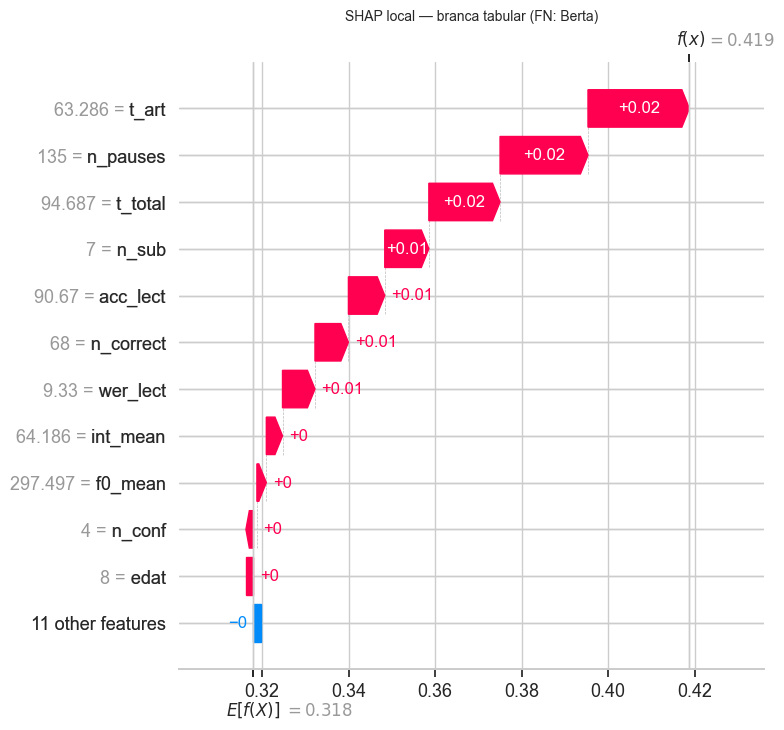


p_tab=0.127   p_spec=0.160   p_final=0.143   (llindar=0.265)


In [9]:
import shap

# Fals(os) negatiu(s): positius reals predits com a típics
fn_idx = np.where((df_errors['tipus_error'] == 'FN').values)[0]

if len(fn_idx) == 0:
    print('No hi ha cap fals negatiu al hold-out.')
else:
    i = int(fn_idx[0])                       # primer FN (n'hi ha 1)
    fn_nom = df_errors.iloc[i]['nom']

    # SHAP local sobre la branca TABULAR (LogReg), coherent amb el bloc 06
    scaler = TAB_MODEL.named_steps['scaler']
    clf    = TAB_MODEL.named_steps['clf']
    bg     = shap.sample(scaler.transform(Xt_tr), 50, random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(clf.predict_proba, bg)

    x_fn = scaler.transform(Xt_ho[i:i + 1])
    raw  = explainer.shap_values(x_fn, nsamples=200)
    if isinstance(raw, list):                       # [cls0, cls1]
        sv, base = raw[1][0], explainer.expected_value[1]
    elif hasattr(raw, 'ndim') and raw.ndim == 3:    # (n, f, cls)
        sv, base = raw[0, :, 1], explainer.expected_value[1]
    else:
        sv, base = raw[0], explainer.expected_value

    expl = shap.Explanation(values=sv, base_values=base,
                            data=Xt_ho[i], feature_names=list(FEAT_NAMES))
    shap.plots.waterfall(expl, max_display=12, show=False)
    plt.title(f'SHAP local — branca tabular (FN: {fn_nom})', fontsize=10)
    plt.tight_layout()
    plt.savefig('./imatges/millor_model_shap_fn.pdf', bbox_inches='tight')
    plt.show()

    print(f'\np_tab={df_errors.iloc[i]["p_tab"]:.3f}   '
          f'p_spec={df_errors.iloc[i]["p_spec"]:.3f}   '
          f'p_final={df_errors.iloc[i]["prob_hibrida"]:.3f}   '
          f'(llindar={thr_hybrid:.3f})')

### 5.3 Mini-taula dels tres positius

Taula de 3 files amb les *features* de fluïdesa clau (ritme, pauses, errors de lectura) i les
probabilitats per branca. Permet veure si el perfil del fals negatiu és genuïnament més proper als
lectors típics en les dimensions mesurades, i contextualitza els dos encerts. S'afegeix la mitjana
dels negatius del hold-out com a referència.

In [10]:
# ── Mini-taula dels 3 positius: fluïdesa + probabilitats per branca ──────────────
# Features clau de fluïdesa lectora: ritme, pauses i errors de lectura.
cand = ['r_art', 't_pauses', 'm_pauses', 'n_err', 'wer_lect', 'acc_lect']
fluency_feats = [f for f in cand if f in list(FEAT_NAMES)]
fidx = {f: list(FEAT_NAMES).index(f) for f in fluency_feats}

def profile_row(j, nom, tipus):
    d = {'nom': nom, 'tipus': tipus}
    d.update({f: Xt_ho[j, fidx[f]] for f in fluency_feats})
    d['p_tab']   = p_tab_ho[j]
    d['p_spec']  = p_spec_ho[j]
    d['p_final'] = p_hold[j]
    return d

rows = [profile_row(j, df_errors.iloc[j]['nom'], df_errors.iloc[j]['tipus_error'])
        for j in np.where(y_ho == 1)[0]]

# Referència: mitjana dels lectors típics (negatius) del hold-out
neg = (y_ho == 0)
ref = {'nom': '— mitjana típics —', 'tipus': 'TN'}
ref.update({f: Xt_ho[neg, fidx[f]].mean() for f in fluency_feats})
ref['p_tab'], ref['p_spec'], ref['p_final'] = (p_tab_ho[neg].mean(),
                                               p_spec_ho[neg].mean(),
                                               p_hold[neg].mean())
mini = pd.DataFrame(rows + [ref])

print('Perfil dels 3 positius vs. mitjana de lectors típics (valors en unitats naturals):')
print(mini.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

Perfil dels 3 positius vs. mitjana de lectors típics (valors en unitats naturals):
               nom tipus  r_art  t_pauses  m_pauses  n_err  wer_lect  acc_lect  p_tab  p_spec  p_final
             Berta    FN  0.668    30.743     0.228  7.000     9.330    90.670  0.127   0.160    0.143
              Ivet    OK  0.615    34.261     0.254 20.000    26.670    73.330  0.620   0.135    0.378
             Sofia    OK  0.566    51.560     0.318 13.000    17.330    84.000  0.310   0.284    0.297
— mitjana típics —    TN  0.648    19.603     0.258  3.500     4.667    95.847  0.049   0.067    0.058


## 6. Visualitzacions: matriu de confusió, ROC i PR

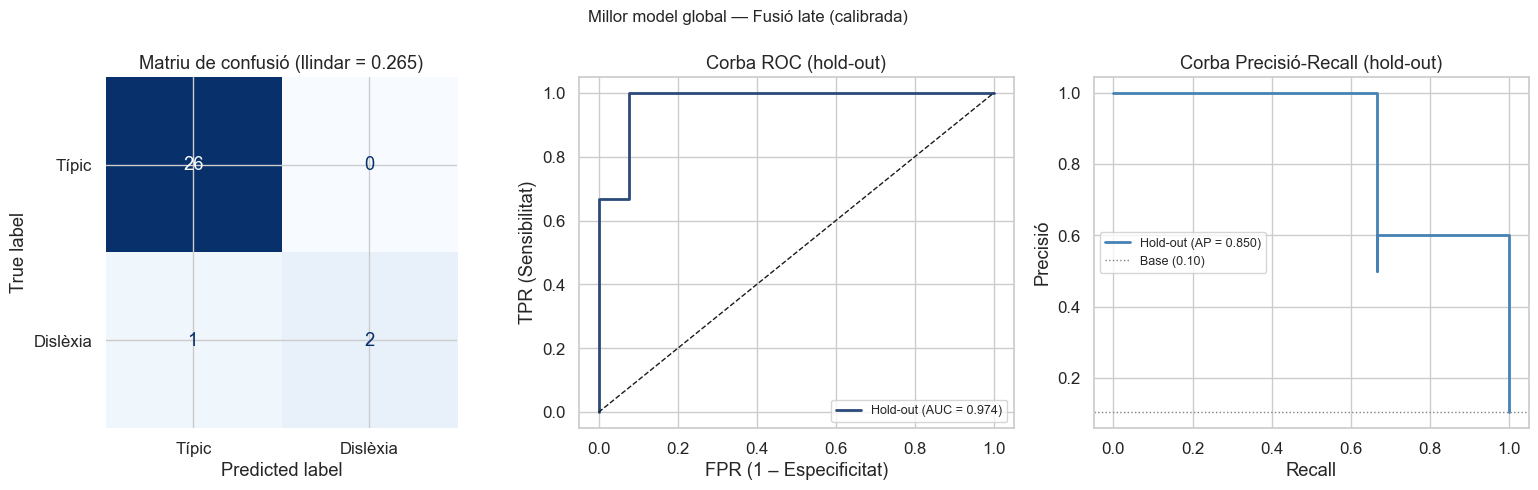

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Matriu de confusió
ConfusionMatrixDisplay.from_predictions(
    y_ho, y_pred,
    display_labels=['Típic', 'Dislèxia'],
    colorbar=False, cmap='Blues', ax=axes[0]
)
for spine in axes[0].spines.values():
    spine.set_visible(False)
axes[0].set_title(f'Matriu de confusió (llindar = {thr_hybrid:.3f})')

# Corba ROC hold-out
fpr, tpr, _ = roc_curve(y_ho, p_hold)
roc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#2a4a7a', lw=2, label=f'Hold-out (AUC = {roc_val:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('FPR (1 – Especificitat)')
axes[1].set_ylabel('TPR (Sensibilitat)')
axes[1].set_title('Corba ROC (hold-out)')
axes[1].legend(fontsize=9)

# Corba PR hold-out
prec, rec, _ = precision_recall_curve(y_ho, p_hold)
ap_val = auc(rec, prec)
axes[2].step(rec, prec, color='steelblue', lw=2, where='post', label=f'Hold-out (AP = {ap_val:.3f})')
base = float(np.mean(y_ho))
axes[2].axhline(base, color='gray', ls=':', lw=1, label=f'Base ({base:.2f})')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precisió')
axes[2].set_title('Corba Precisió-Recall (hold-out)')
axes[2].legend(fontsize=9)

plt.suptitle(f'Millor model global — {hyb_ho_json["estrategia"]}', fontsize=12)
plt.tight_layout()
plt.savefig('./imatges/millor_model_holdout_eval.pdf', bbox_inches='tight')
plt.show()


## 7. Visualització PCA: errors en el hold-out

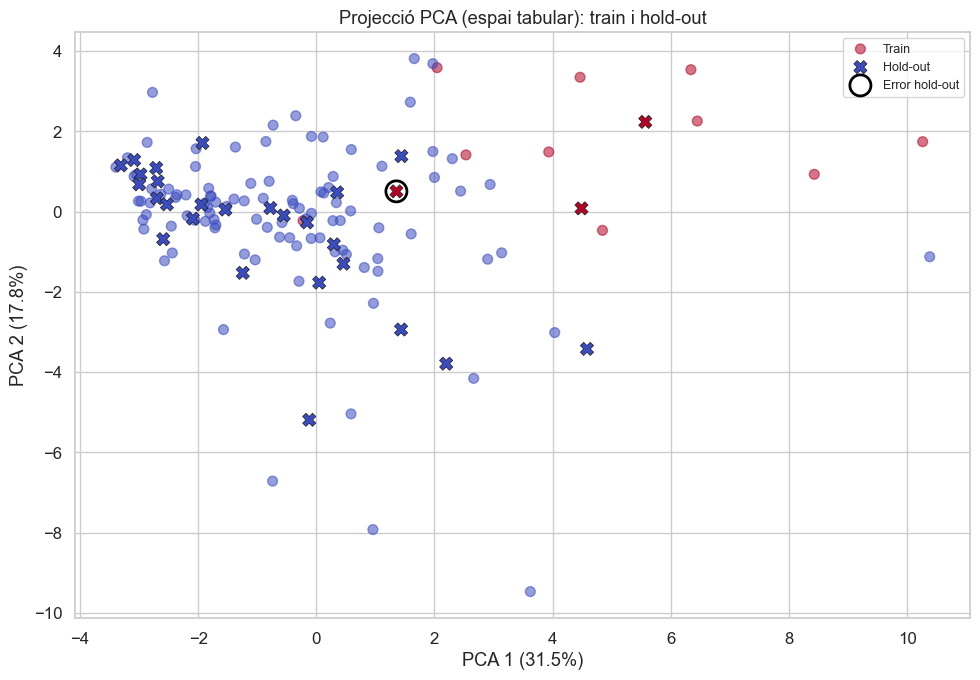

In [15]:
# PCA sobre l'espai tabular (22 característiques) per visualitzar la distribució
# dels infants i marcar els errors del hold-out.
scaler_pca = StandardScaler()
X_train_sc = scaler_pca.fit_transform(Xt_tr)
X_hold_sc  = scaler_pca.transform(Xt_ho)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)
X_hold_pca  = pca.transform(X_hold_sc)

error_mask = ~df_errors['correcte'].values  # booleà: True = error

fig, ax = plt.subplots(figsize=(10, 7))

# Train: cercles petits, colorats per classe
scatter_tr = ax.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_tr, cmap='coolwarm', alpha=0.55, s=50, label='Train'
)
# Hold-out: creus, colorades per classe real
scatter_ho = ax.scatter(
    X_hold_pca[:, 0], X_hold_pca[:, 1],
    c=y_ho, cmap='coolwarm', marker='X', s=90, edgecolors='k', linewidths=0.5,
    label='Hold-out'
)
# Errors hold-out: cercle negre al voltant
if error_mask.any():
    ax.scatter(
        X_hold_pca[error_mask, 0], X_hold_pca[error_mask, 1],
        facecolors='none', edgecolors='black', s=230, linewidths=2,
        label='Error hold-out'
    )
else:
    ax.text(0.5, 0.97, 'Cap error en el hold-out', ha='center', va='top',
            transform=ax.transAxes, fontsize=10, color='green')

ax.set_xlabel(f'PCA 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PCA 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Projecció PCA (espai tabular): train i hold-out')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('./imatges/millor_model_pca_holdout.pdf', bbox_inches='tight')
plt.show()


## 8. Resum consolidat


In [16]:
n_errors   = int((~df_errors['correcte']).sum())
n_fp       = int((df_errors['tipus_error'] == 'FP').sum())
n_fn       = int((df_errors['tipus_error'] == 'FN').sum())

print('=' * 72)
print('   MILLOR MODEL GLOBAL — RESUM CONSOLIDAT')
print('=' * 72)

print('\n1) COMPARACIÓ DELS TRES BLOCS (mètrica de selecció: AUC-ROC CV)')
print(f"   {'Bloc':20s}  {'AUC-ROC CV':>12s}  {'IC 95% CV':>18s}  {'p':>6s}  {'AUC-ROC HO':>11s}")
print(f"   {'-'*20}  {'-'*12}  {'-'*18}  {'-'*6}  {'-'*11}")
print(f"   {'06 — Tabular':20s}  "
      f"{best_tab['auc_roc_nested']:12.3f}  "
      f"  [{best_tab['roc_lo']:.3f},{best_tab['roc_hi']:.3f}]  "
      f"{best_tab['p_roc']:6.3f}  {'—':>11s}")
print(f"   {'07 — Espectral':20s}  "
      f"{spec_ho['cv_auc_roc']:12.3f}  "
      f"  [{spec_ho['cv_roc_lo']:.3f},{spec_ho['cv_roc_hi']:.3f}]  "
      f"{spec_ho['cv_p_roc']:6.3f}  "
      f"{spec_ho['holdout_auc_roc']:11.3f}")
print(f"   {'08 — Híbrid  ★':20s}  "
      f"{hyb_ho_json['cv_auc_roc']:12.3f}  "
      f"  [{hyb_ho_json['cv_roc_ci'][0]:.3f},{hyb_ho_json['cv_roc_ci'][1]:.3f}]  "
      f"{hyb_ho_json['cv_p_roc']:6.3f}  "
      f"{m_ho['roc_auc']:11.3f}")

print(f'\n2) MILLOR MODEL GLOBAL: {hyb_ho_json["estrategia"]}  (bloc 08)')
print(f'   Llindar (F2 màx. sobre OOF): {thr_hybrid:.4f}')
print(f'\n3) MÈTRIQUES HOLD-OUT  (n={int(y_ho.sum()) + int((y_ho==0).sum())}, '
      f'positius={int(y_ho.sum())})')
print(f'   {"Mètrica":18s}  {"Valor":>8s}')
print(f'   {"-"*18}  {"-"*8}')
for name, val in [('AUC-ROC',      m_ho['roc_auc']),
                  ('AUC-PR',       m_ho['pr_auc']),
                  ('F1',           m_ho['f1']),
                  ('F2',           m_ho['f2']),
                  ('Sensibilitat', m_ho['recall']),
                  ('Especificitat',m_ho['specificity'])]:
    print(f'   {name:18s}  {val:8.3f}')

print(f'\n4) ERRORS sobre hold-out: {n_errors} / {len(df_hold)}  '
      f'(FP: {n_fp}, FN: {n_fn})')
if n_errors > 0:
    for _, row in errors.iterrows():
        print(f'   {row["nom"]:20s}  real={int(row["dislexia"])}  '
              f'pred={int(row["pred"])}  prob={row["prob_hibrida"]:.3f}  '
              f'[{row["tipus_error"]}]')
else:
    print('   Cap error.')
print('=' * 72)


   MILLOR MODEL GLOBAL — RESUM CONSOLIDAT

1) COMPARACIÓ DELS TRES BLOCS (mètrica de selecció: AUC-ROC CV)
   Bloc                    AUC-ROC CV           IC 95% CV       p   AUC-ROC HO
   --------------------  ------------  ------------------  ------  -----------
   06 — Tabular                 0.916    [0.738,0.982]   0.002            —
   07 — Espectral               0.912    [0.840,0.966]   0.002        0.910
   08 — Híbrid  ★               0.945    [0.858,1.000]   0.002        0.974

2) MILLOR MODEL GLOBAL: Fusió late (calibrada)  (bloc 08)
   Llindar (F2 màx. sobre OOF): 0.2651

3) MÈTRIQUES HOLD-OUT  (n=29, positius=3)
   Mètrica                Valor
   ------------------  --------
   AUC-ROC                0.974
   AUC-PR                 0.867
   F1                     0.800
   F2                     0.714
   Sensibilitat           0.667
   Especificitat          1.000

4) ERRORS sobre hold-out: 1 / 29  (FP: 0, FN: 1)
   Berta                 real=1  pred=0  prob=0.143  [FN]
